# Baseline vs. GT-guided auxiliary comparison

This notebook compares the two completed runs on the same VOC2007 validation split. It shows official VOC2007 AP@0.5 as well as COCO-style AP, AP50, AP75, size-specific AP and AR. It also draws weighted-loss, component-loss, learning-rate, epoch-time and GPU-memory curves.

> VOC2007 officially specifies AP@0.5. COCO-style metrics here use the same VOC annotations with COCO IoU/area thresholds; VOC `difficult` instances are ignored during matching.

In [4]:
from __future__ import annotations

import csv
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from gt_guided_dino.api import compute_coco_metrics, evaluate_checkpoint
from gt_guided_dino.config import ExperimentConfig
from gt_guided_dino.data import build_datasets

In [5]:
# Change SEED if the two runs used a seed other than 42.
SEED = 42
BASELINE_CHECKPOINT = PROJECT_ROOT / 'artifacts' / 'baseline' / f'seed_{SEED}' / 'checkpoints' / 'latest.pt'
PROPOSED_CHECKPOINT = PROJECT_ROOT / 'artifacts' / 'gt_guided_aux' / f'seed_{SEED}' / 'checkpoints' / 'latest.pt'

# Set True only when evaluation.json is missing or you want to regenerate it.
# Full VOC2007 validation takes time for each checkpoint.
RUN_EVALUATION_IF_MISSING = False
EVALUATION_PRECISION = 'fp16'  # 'fp16' on CUDA, otherwise use 'fp32'

for name, path in {'baseline': BASELINE_CHECKPOINT, 'gt_guided_aux': PROPOSED_CHECKPOINT}.items():
    if not path.is_file():
        raise FileNotFoundError(f'{name} checkpoint not found: {path}')
print('Baseline:', BASELINE_CHECKPOINT)
print('Proposed:', PROPOSED_CHECKPOINT)

Baseline: D:\gt-guided_aux_loc_path\artifacts\baseline\seed_42\checkpoints\latest.pt
Proposed: D:\gt-guided_aux_loc_path\artifacts\gt_guided_aux\seed_42\checkpoints\latest.pt


In [6]:
def load_or_evaluate(checkpoint: Path) -> dict:
    evaluation_path = checkpoint.parent.parent / 'evaluation.json'
    if evaluation_path.is_file() and not RUN_EVALUATION_IF_MISSING:
        return json.loads(evaluation_path.read_text(encoding='utf-8'))
    if not RUN_EVALUATION_IF_MISSING:
        raise FileNotFoundError(
            f'Missing {evaluation_path}. Run 02_evaluate.ipynb first, or set '
            'RUN_EVALUATION_IF_MISSING = True.'
        )
    return evaluate_checkpoint(
        checkpoint,
        data_root=PROJECT_ROOT / 'VOC2007',
        precision=EVALUATION_PRECISION,
    )

baseline_result = load_or_evaluate(BASELINE_CHECKPOINT)
proposed_result = load_or_evaluate(PROPOSED_CHECKPOINT)
print(f"Baseline: {baseline_result['metrics']['images']} images, {baseline_result['metrics']['seconds']:.1f}s")
print(f"Proposed: {proposed_result['metrics']['images']} images, {proposed_result['metrics']['seconds']:.1f}s")

Baseline: 2510 images, 539.1s
Proposed: 2510 images, 531.7s


In [7]:
def validation_dataset_from_checkpoint(checkpoint: Path):
    payload = torch.load(checkpoint, map_location='cpu', weights_only=False)
    config = ExperimentConfig.from_dict(payload['config'], data_root=PROJECT_ROOT / 'VOC2007')
    return build_datasets(config)[1]

baseline_dataset = validation_dataset_from_checkpoint(BASELINE_CHECKPOINT)
proposed_dataset = validation_dataset_from_checkpoint(PROPOSED_CHECKPOINT)
if baseline_dataset.image_ids != proposed_dataset.image_ids:
    raise ValueError('The two checkpoints use different validation image sets.')

baseline_coco = compute_coco_metrics(baseline_result['predictions'], baseline_dataset)
proposed_coco = compute_coco_metrics(proposed_result['predictions'], proposed_dataset)
print('COCO-style metrics calculated on', len(baseline_dataset), 'VOC2007 validation images.')

creating index...
index created!
Loading and preparing results...
DONE (t=0.77s)
creating index...
index created!
creating index...
index created!
Loading and preparing results...
DONE (t=0.68s)
creating index...
index created!
COCO-style metrics calculated on 2510 VOC2007 validation images.


In [8]:
def value_table(rows):
    header = '| Metric | Baseline | GT-guided auxiliary | Delta |\n|---|---:|---:|---:|'
    body = []
    for label, baseline_value, proposed_value in rows:
        body.append(
            f'| {label} | {baseline_value:.4f} | {proposed_value:.4f} | {proposed_value - baseline_value:+.4f} |'
        )
    display(Markdown('\n'.join([header, *body])))

summary_keys = ('AP', 'AP50', 'AP75', 'AP_small', 'AP_medium', 'AP_large', 'AR_1', 'AR_10', 'AR_100', 'AR_small', 'AR_medium', 'AR_large')
summary_rows = [(key, baseline_coco[key], proposed_coco[key]) for key in summary_keys]
summary_rows += [
    ('VOC07_mAP50', baseline_result['metrics']['voc07_map50'], proposed_result['metrics']['voc07_map50']),
    ('VOC_integral_mAP50', baseline_result['metrics']['voc_map50_integral'], proposed_result['metrics']['voc_map50_integral']),
]
value_table(summary_rows)

| Metric | Baseline | GT-guided auxiliary | Delta |
|---|---:|---:|---:|
| AP | 0.2523 | 0.2438 | -0.0085 |
| AP50 | 0.4107 | 0.3826 | -0.0282 |
| AP75 | 0.2661 | 0.2649 | -0.0013 |
| AP_small | 0.1139 | 0.0782 | -0.0357 |
| AP_medium | 0.1606 | 0.1484 | -0.0122 |
| AP_large | 0.2945 | 0.2897 | -0.0048 |
| AR_1 | 0.3549 | 0.3566 | +0.0016 |
| AR_10 | 0.5460 | 0.5494 | +0.0034 |
| AR_100 | 0.6742 | 0.6701 | -0.0041 |
| AR_small | 0.3061 | 0.2081 | -0.0980 |
| AR_medium | 0.5346 | 0.5130 | -0.0216 |
| AR_large | 0.7411 | 0.7432 | +0.0022 |
| VOC07_mAP50 | 0.4195 | 0.3928 | -0.0267 |
| VOC_integral_mAP50 | 0.4079 | 0.3793 | -0.0287 |

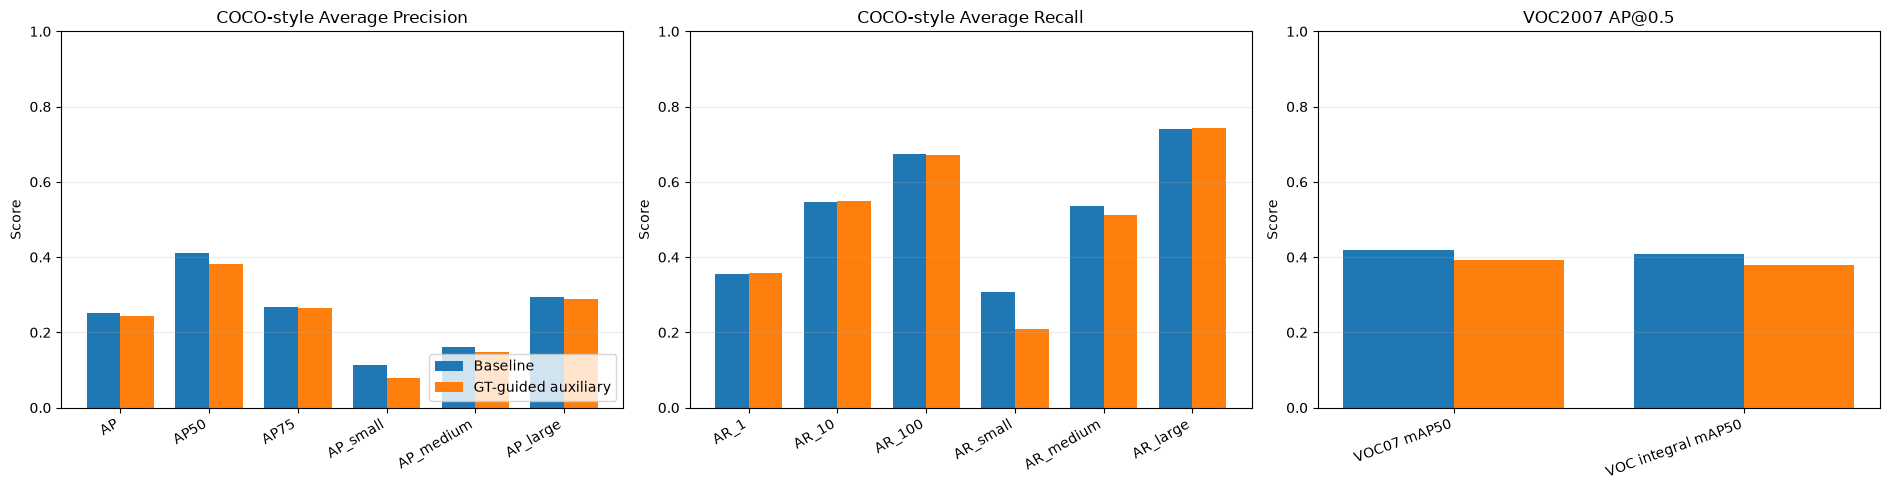

In [9]:
def grouped_bars(axis, keys, title):
    positions = np.arange(len(keys))
    width = 0.38
    axis.bar(positions - width / 2, [baseline_coco[key] for key in keys], width, label='Baseline')
    axis.bar(positions + width / 2, [proposed_coco[key] for key in keys], width, label='GT-guided auxiliary')
    axis.set_xticks(positions, keys, rotation=30, ha='right')
    axis.set_ylim(0, 1)
    axis.set_ylabel('Score')
    axis.set_title(title)
    axis.grid(axis='y', alpha=0.25)

figure, axes = plt.subplots(1, 3, figsize=(19, 5))
grouped_bars(axes[0], ('AP', 'AP50', 'AP75', 'AP_small', 'AP_medium', 'AP_large'), 'COCO-style Average Precision')
grouped_bars(axes[1], ('AR_1', 'AR_10', 'AR_100', 'AR_small', 'AR_medium', 'AR_large'), 'COCO-style Average Recall')
voc_keys = ('voc07_map50', 'voc_map50_integral')
positions = np.arange(len(voc_keys))
axes[2].bar(positions - 0.19, [baseline_result['metrics'][key] for key in voc_keys], 0.38, label='Baseline')
axes[2].bar(positions + 0.19, [proposed_result['metrics'][key] for key in voc_keys], 0.38, label='GT-guided auxiliary')
axes[2].set_xticks(positions, ('VOC07 mAP50', 'VOC integral mAP50'), rotation=20, ha='right')
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('Score')
axes[2].set_title('VOC2007 AP@0.5')
axes[2].grid(axis='y', alpha=0.25)
axes[0].legend(loc='lower right')
figure.tight_layout()

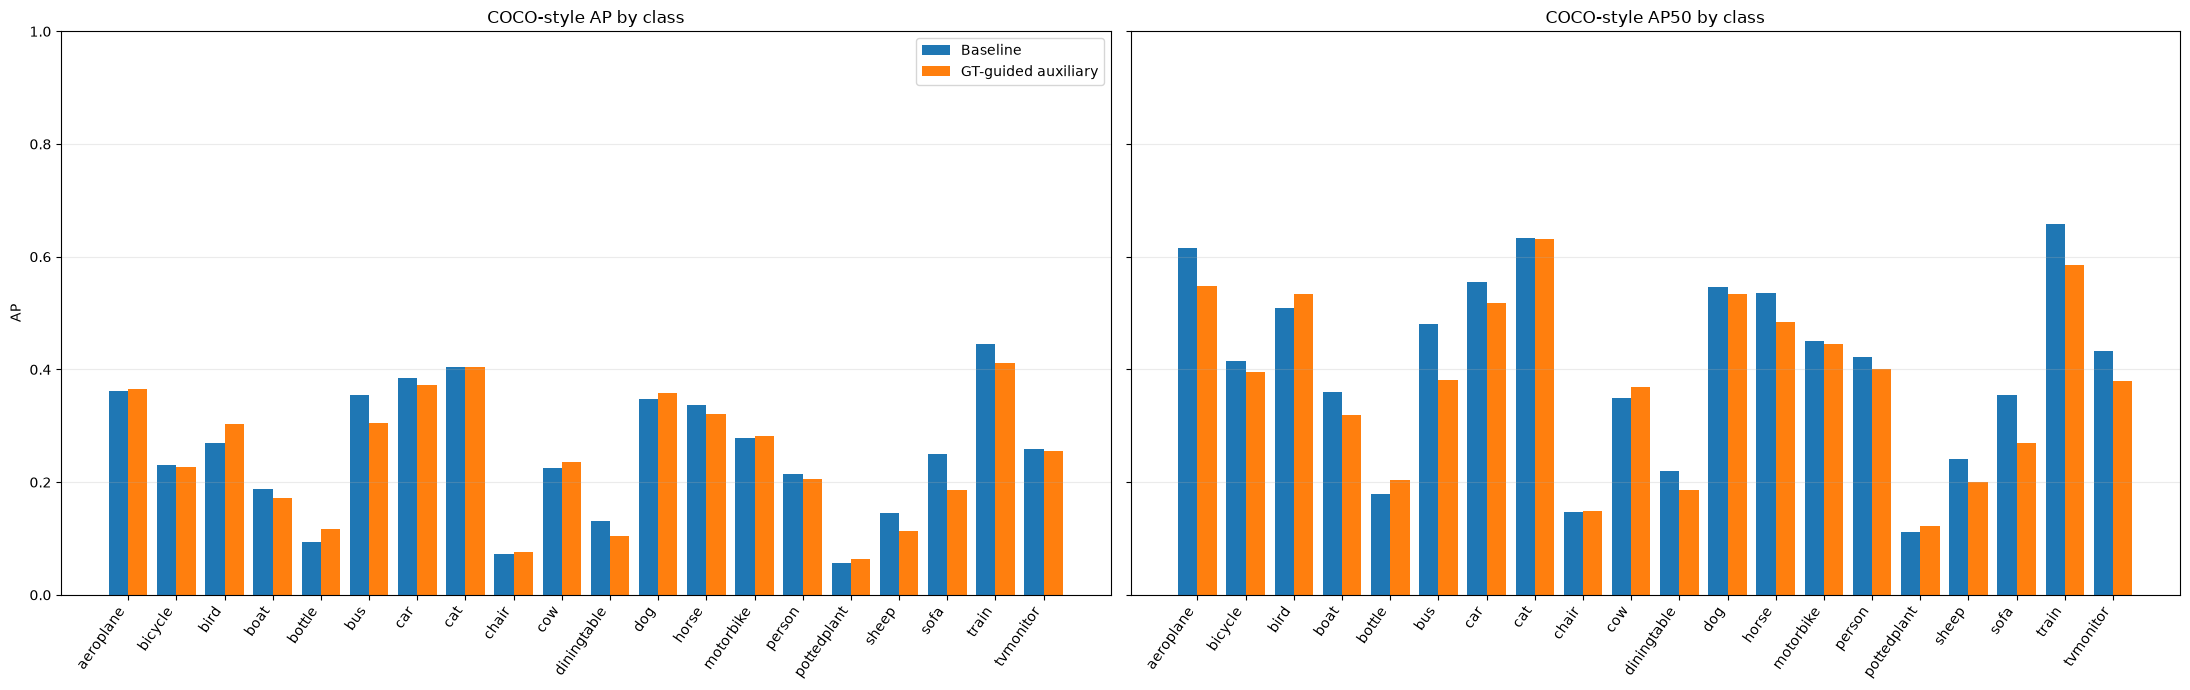

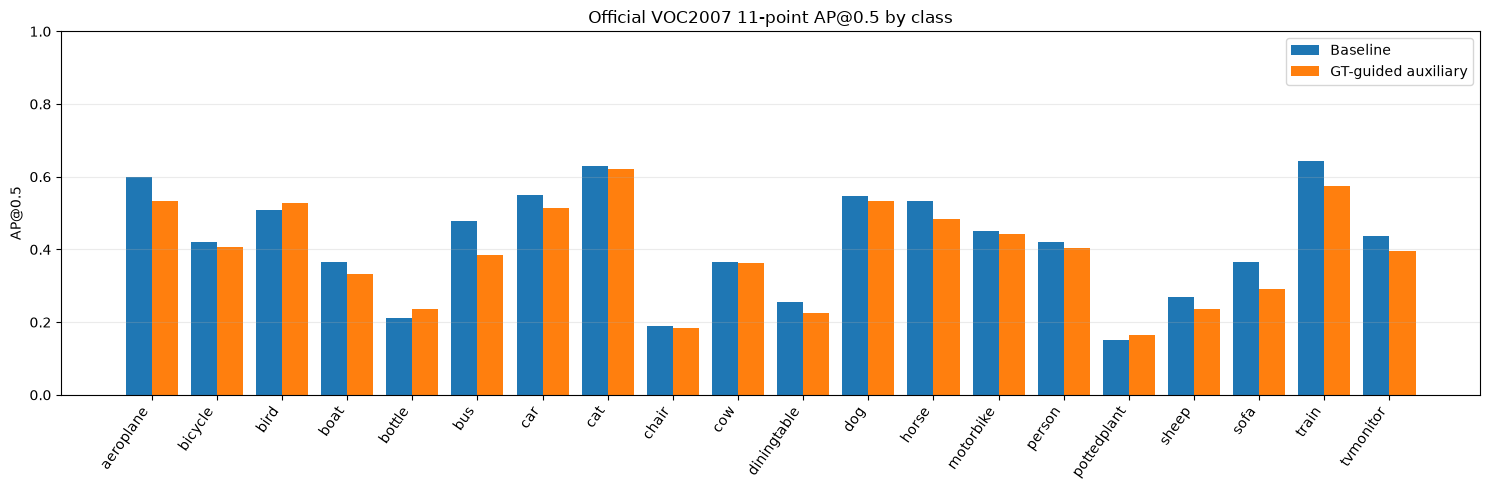

In [10]:
classes = list(baseline_coco['AP_by_class'])
positions = np.arange(len(classes))
figure, axes = plt.subplots(1, 2, figsize=(22, 7), sharey=True)
for axis, metric_key, title in (
    (axes[0], 'AP_by_class', 'COCO-style AP by class'),
    (axes[1], 'AP50_by_class', 'COCO-style AP50 by class'),
):
    axis.bar(positions - 0.2, [baseline_coco[metric_key][name] for name in classes], 0.4, label='Baseline')
    axis.bar(positions + 0.2, [proposed_coco[metric_key][name] for name in classes], 0.4, label='GT-guided auxiliary')
    axis.set_xticks(positions, classes, rotation=55, ha='right')
    axis.set_ylim(0, 1)
    axis.set_title(title)
    axis.grid(axis='y', alpha=0.25)
axes[0].set_ylabel('AP')
axes[0].legend()
figure.tight_layout()

# Official VOC2007 per-class AP@0.5 (11-point interpolation).
voc_classes = list(baseline_result['metrics']['ap50_voc07_by_class'])
figure, axis = plt.subplots(figsize=(15, 5))
axis.bar(positions - 0.2, [baseline_result['metrics']['ap50_voc07_by_class'][name] for name in voc_classes], 0.4, label='Baseline')
axis.bar(positions + 0.2, [proposed_result['metrics']['ap50_voc07_by_class'][name] for name in voc_classes], 0.4, label='GT-guided auxiliary')
axis.set_xticks(positions, voc_classes, rotation=55, ha='right')
axis.set_ylim(0, 1)
axis.set_ylabel('AP@0.5')
axis.set_title('Official VOC2007 11-point AP@0.5 by class')
axis.legend()
axis.grid(axis='y', alpha=0.25)
figure.tight_layout()

In [11]:
def read_history(checkpoint: Path):
    history_path = checkpoint.parent.parent / 'history.csv'
    if not history_path.is_file():
        raise FileNotFoundError(f'Training history not found: {history_path}')
    with history_path.open(encoding='utf-8', newline='') as handle:
        rows = list(csv.DictReader(handle))
    return [{key: float(value) if value not in ('', None) else np.nan for key, value in row.items()} for row in rows]

histories = {
    'Baseline': read_history(BASELINE_CHECKPOINT),
    'GT-guided auxiliary': read_history(PROPOSED_CHECKPOINT),
}
for name, history in histories.items():
    print(f'{name}: {len(history)} epoch(s), final weighted loss = {history[-1]["loss"]:.4f}')

Baseline: 12 epoch(s), final weighted loss = 11.9361
GT-guided auxiliary: 12 epoch(s), final weighted loss = 12.4081


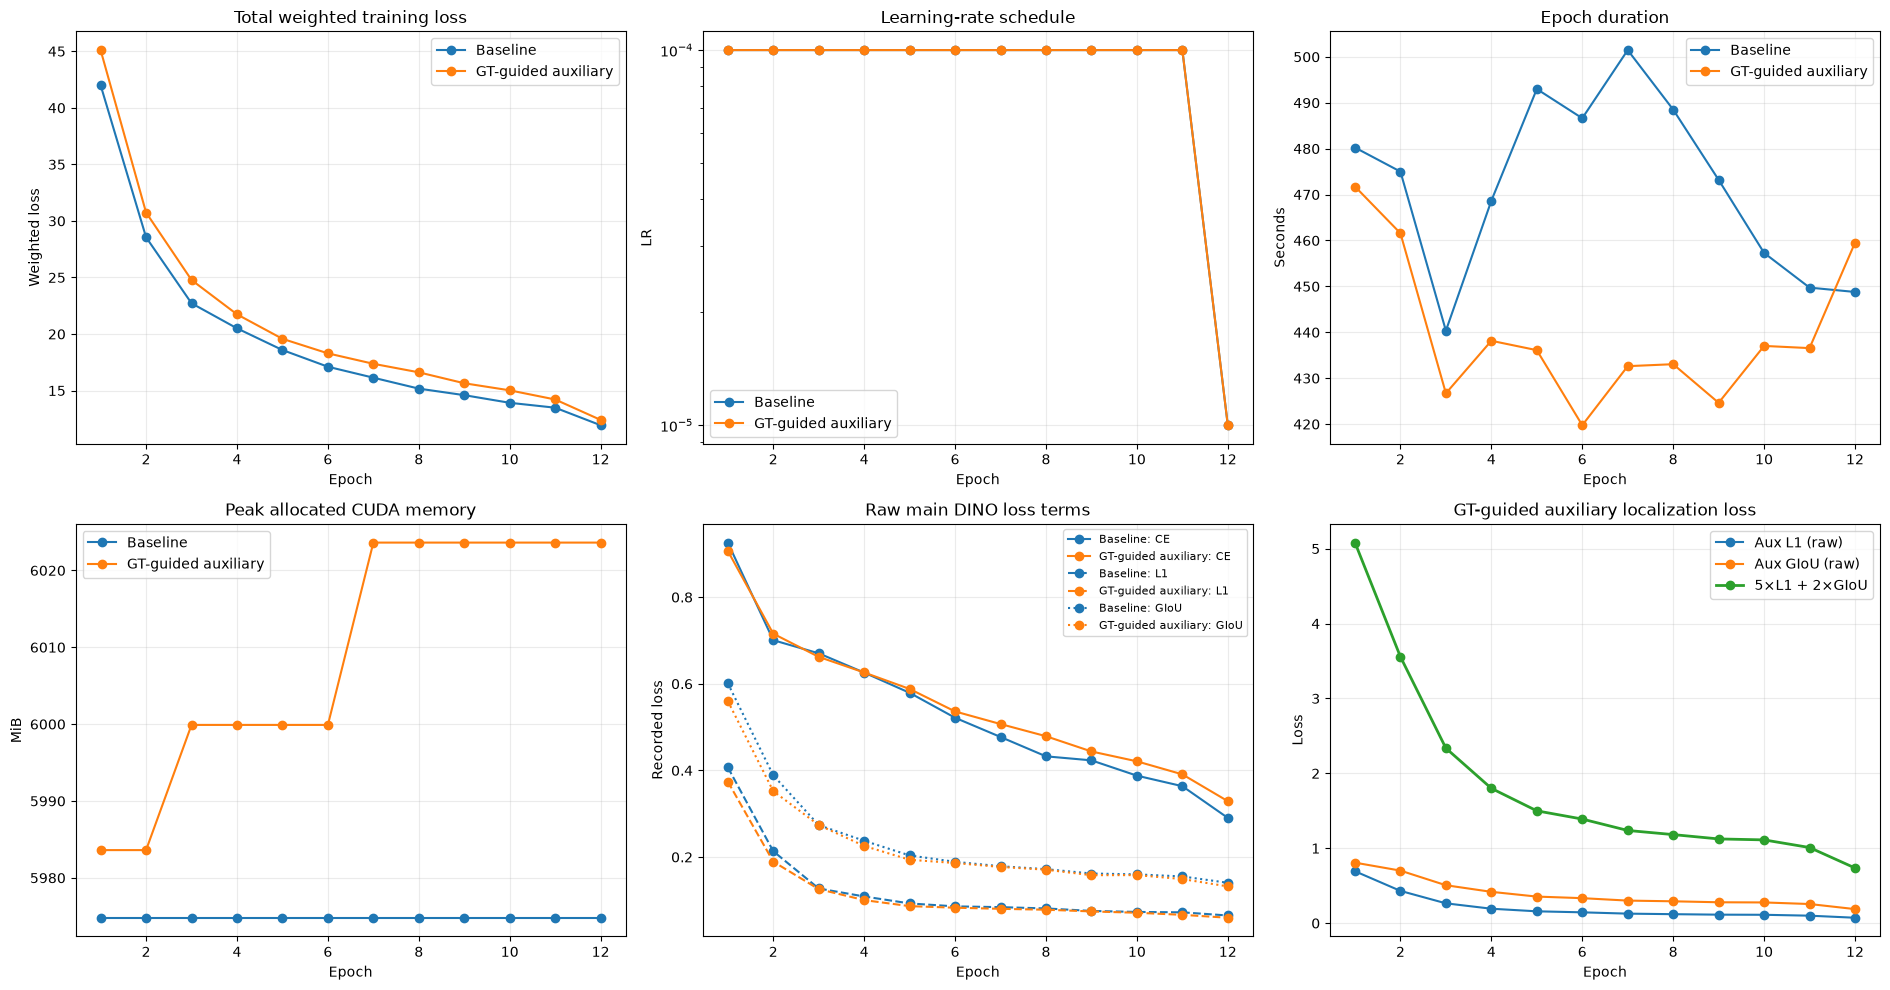

In [12]:
COLORS = {'Baseline': 'tab:blue', 'GT-guided auxiliary': 'tab:orange'}

def plot_series(axis, key, title, ylabel, *, log_scale=False):
    plotted = False
    for name, history in histories.items():
        values = np.asarray([row.get(key, np.nan) for row in history], dtype=float)
        if np.isfinite(values).any():
            axis.plot([row['epoch'] for row in history], values, marker='o', label=name, color=COLORS[name])
            plotted = True
    axis.set(title=title, xlabel='Epoch', ylabel=ylabel)
    if log_scale:
        axis.set_yscale('log')
    axis.grid(alpha=0.25)
    if plotted:
        axis.legend()

figure, axes = plt.subplots(2, 3, figsize=(19, 10))
plot_series(axes[0, 0], 'loss', 'Total weighted training loss', 'Weighted loss')
plot_series(axes[0, 1], 'lr', 'Learning-rate schedule', 'LR', log_scale=True)
plot_series(axes[0, 2], 'seconds', 'Epoch duration', 'Seconds')
plot_series(axes[1, 0], 'peak_cuda_mb', 'Peak allocated CUDA memory', 'MiB')

# Main loss terms are the raw DINO criterion values recorded before their 1/5/2 weights.
for key, label, style in (('loss_ce', 'CE', '-'), ('loss_bbox', 'L1', '--'), ('loss_giou', 'GIoU', ':')):
    for name, history in histories.items():
        values = np.asarray([row.get(key, np.nan) for row in history], dtype=float)
        if np.isfinite(values).any():
            axes[1, 1].plot([row['epoch'] for row in history], values, linestyle=style, marker='o', color=COLORS[name], label=f'{name}: {label}')
axes[1, 1].set(title='Raw main DINO loss terms', xlabel='Epoch', ylabel='Recorded loss')
axes[1, 1].grid(alpha=0.25)
axes[1, 1].legend(fontsize=8)

proposal_history = histories['GT-guided auxiliary']
epochs = [row['epoch'] for row in proposal_history]
aux_l1 = np.asarray([row.get('loss_aux_bbox', np.nan) for row in proposal_history], dtype=float)
aux_giou = np.asarray([row.get('loss_aux_giou', np.nan) for row in proposal_history], dtype=float)
if np.isfinite(aux_l1).any():
    axes[1, 2].plot(epochs, aux_l1, marker='o', label='Aux L1 (raw)')
    axes[1, 2].plot(epochs, aux_giou, marker='o', label='Aux GIoU (raw)')
    axes[1, 2].plot(epochs, 5 * aux_l1 + 2 * aux_giou, marker='o', linewidth=2, label='5×L1 + 2×GIoU')
axes[1, 2].set(title='GT-guided auxiliary localization loss', xlabel='Epoch', ylabel='Loss')
axes[1, 2].grid(alpha=0.25)
axes[1, 2].legend()
figure.tight_layout()

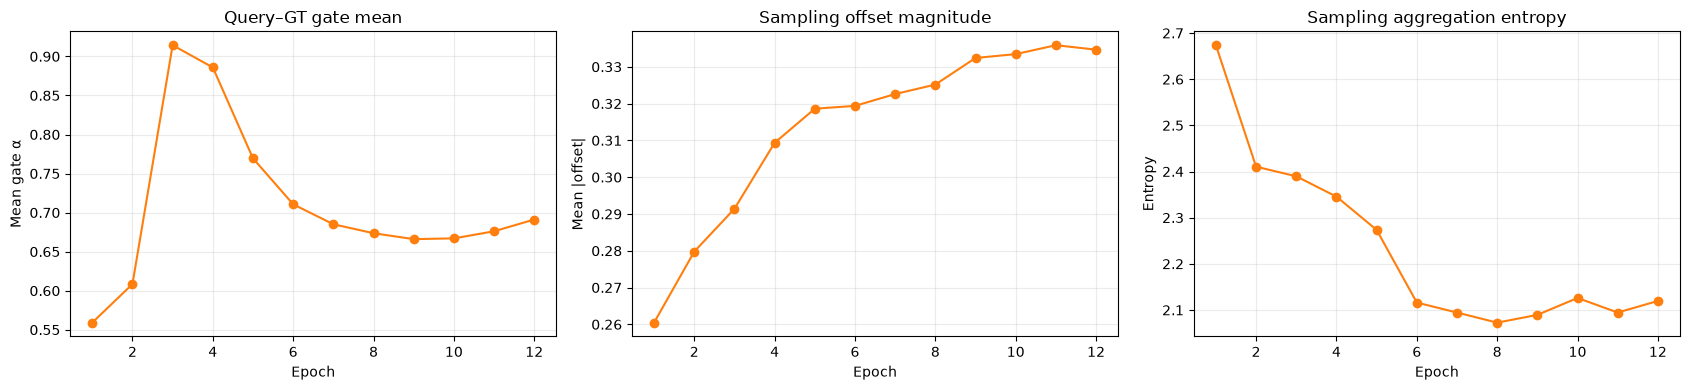

In [13]:
figure, axes = plt.subplots(1, 3, figsize=(17, 4))
for axis, key, title, ylabel in (
    (axes[0], 'aux_gate_mean', 'Query–GT gate mean', 'Mean gate α'),
    (axes[1], 'aux_offset_abs_mean', 'Sampling offset magnitude', 'Mean |offset|'),
    (axes[2], 'aux_attention_entropy', 'Sampling aggregation entropy', 'Entropy'),
):
    values = np.asarray([row.get(key, np.nan) for row in proposal_history], dtype=float)
    if np.isfinite(values).any():
        axis.plot(epochs, values, marker='o', color=COLORS['GT-guided auxiliary'])
    axis.set(title=title, xlabel='Epoch', ylabel=ylabel)
    axis.grid(alpha=0.25)
figure.tight_layout()